# Reconstructing images
I use both direct and undirect reconstructions, helpful for comparisons.

to change the model, overwrite:

- MODEL variable;
- QUANT_TABLES variable if necessary;
- the degradation function.

In [ ]:
tot_generated_images = 100

## Importing and Loading

In [ ]:
! pip install kornia
! pip install torch_dct
! pip install torchgeometry


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 2.2 MB/s eta 0:00:00


In [ ]:
# Imports
import random
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import torch
import os
import sys
from pathlib import Path

import kornia
import torch_dct as dct

from torch._prims_common import check
from collections import OrderedDict
import copy

import glob
from PIL import Image
import torchvision.utils as vutils

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Base path
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" if 'google.colab' in str(get_ipython()) else "."
NAME = "01_recon_torch_dct"
MODEL = "01_torch_dct"

# Directories
ZIP_PATH = os.path.join(BASE_DIR, "data", "img_align_celeba.zip")
LOCAL_DATA_ROOT = "/content/raw_data"
SRC_C_D = os.path.join(BASE_DIR, "src", "Cold-Diffusion-Models", "resolution-diffusion-pytorch", "resolution_diffusion_pytorch")

CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints", "coeff_truncation", MODEL)
TRAINED_MODEL_DIR = os.path.join(BASE_DIR, "trained_models", "cold_diffusion", "coeff_truncation", MODEL)

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "reconstructions", "coeff_truncation", NAME)

# restoration
VAE_FACES_DIR = os.path.join(BASE_DIR, 'data', 'generated_images')

# importing the models
if SRC_C_D not in sys.path:
    sys.path.append(os.path.dirname(SRC_C_D))

# Folder creation
for path in [CHECKPOINT_DIR, OUTPUT_DIR, TRAINED_MODEL_DIR]:
    os.makedirs(path, exist_ok=True)

In [ ]:
from resolution_diffusion_pytorch import Unet, GaussianDiffusion, Trainer

dataset_path = os.path.join(LOCAL_DATA_ROOT, "img_align_celeba")
model_path = os.path.join(TRAINED_MODEL_DIR, f'{MODEL}.pt')

In [ ]:
# Out Of Memory problems
torch.cuda.synchronize()
gc.collect()
torch.cuda.empty_cache()
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

def new_sample(self, batch_size=16, img=None, t=None):
    '''
    Images direct reconstruction
    '''

    if t is None:
        t = self.num_timesteps

    xt = img # image at maximum degraded step

    direct_recons = None

    while t:
        with torch.no_grad():
            step = torch.full((batch_size,), t - 1, dtype=torch.long).cuda()
            # Denoise x_t to get an estimate of x_0 (denoted as 'x')
            x = self.denoise_fn(img, step)

            if self.train_routine == 'Final':
                if direct_recons is None:
                    direct_recons = x

                if self.sampling_routine == 'default':
                    img = jpeg_degradation(x, t - 1)

                elif self.sampling_routine == 'x0_step_down':
                    x_times = jpeg_degradation(x, t)
                    x_times_sub_1 = jpeg_degradation(x, t - 1)
                    img = img - x_times + x_times_sub_1

        t -= 1

    return xt, direct_recons, img

Free GPU memory: 15.53 GB


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 128

def find_last_checkpoint(save_folder):
    path = os.path.join(save_folder, f'model.pt')
    if os.path.exists(path):
        return path
    return None

In [ ]:
from torch._prims_common import check
# --- CONFIGURATION ---
class Args:
    time_steps = 9
    train_steps = 5000
    save_folder = OUTPUT_DIR
    data_path = dataset_path
    checkpoint_path = CHECKPOINT_DIR
    load_path = find_last_checkpoint(checkpoint_path)
    train_routine = 'Final'
    resolution_routine = 'Incremental'
    sampling_routine = 'x0_step_down'
    image_size = IMG_SIZE
    channels = 3

args = Args()

# --- MODEL INITIALIZATION ---
model = Unet(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels = args.channels
).cuda()

diffusion = GaussianDiffusion(
    model,
    image_size = args.image_size,
    device_of_kernel = 'cuda',
    channels = args.channels,
    timesteps = args.time_steps,
    loss_type = 'l1',
    resolution_routine = args.resolution_routine,
    train_routine = args.train_routine,
    sampling_routine = args.sampling_routine
).cuda()

if torch.cuda.device_count() > 1:
    diffusion = torch.nn.DataParallel(diffusion)

Is Time embed used ?  True


In [ ]:
def zigzag():
  return [(i if s % 2 == 0 else s - i, s - i if s % 2 == 0 else i)
          for s in range(15)
          for i in range(s + 1)
          if (i < 8 and s - i < 8)]

def get_degradation_params(step):
    """
    Restituisce (keep_full, half_coeff_idx):
    - keep_full: quanti coefficienti mantenere interi
    - half_coeff_idx: indice del coefficiente da dimezzare (None se nessuno)
    """
    if step == 0:
        return 64, None
    elif step == 1:
        return 9, None
    elif step == 2:
        return 6, None
    elif step == 3:
        return 5, None
    elif step == 4:
        return 4, None
    elif step == 5:
        return 3, None
    elif step == 6:
        return 2, 2
    elif step == 7:
        return 2, None
    elif step == 8:
        return 1, 1
    else:  # step == 9
        return 1, None
import torch_dct as dct
from functools import lru_cache

# Precopmutes masks
_masks_cache = {}

def get_mask(keep_full, half_coeff_idx, device):
    key = (keep_full, half_coeff_idx)
    if key not in _masks_cache:
        zz = zigzag()
        mask = torch.zeros(8, 8, device=device)
        for i, j in zz[:keep_full]:
            mask[i, j] = 1.0
        if half_coeff_idx is not None:
            hi, hj = zz[half_coeff_idx]
            mask[hi, hj] = 0.5
        _masks_cache[key] = mask
    return _masks_cache[key].to(device)


def precompute_all_masks(args, device):
    """Chiama all'inizio per precalcolare tutte le maschere."""
    for step in range(args.time_steps):
        keep_full, half_coeff_idx = get_degradation_params(step)
        get_mask(keep_full, half_coeff_idx, device)
    print(f"Precalcolate {len(_masks_cache)} maschere")

precompute_all_masks(args, device='cuda')


def jpeg_degradation(img_batch, step):
    device = img_batch.device

    current_step = step.item() if torch.is_tensor(step) else step
    keep_full, half_coeff_idx = get_degradation_params(current_step)

    if keep_full == 64:
        return img_batch

    B, C, H, W = img_batch.shape

    mask = get_mask(keep_full, half_coeff_idx, device)

    x = img_batch.half()

    blocks = x.unfold(2, 8, 8).unfold(3, 8, 8)
    bH, bW = blocks.shape[2], blocks.shape[3]

    blocks_flat = blocks.contiguous().reshape(-1, 8, 8)

    blocks_flat_float32 = blocks_flat.float()

    dct_blocks = dct.dct_2d(blocks_flat_float32, norm='ortho') * mask
    result_flat = dct.idct_2d(dct_blocks, norm='ortho')

    result = result_flat.reshape(B, C, bH, bW, 8, 8)
    result = result.permute(0, 1, 2, 4, 3, 5).contiguous().reshape(B, C, H, W)

    return result.float().clamp(-1, 1)

Precalcolate 9 maschere


<!-- ## Resources
[] -->

In [ ]:
trained_model = torch.load(model_path)

new_state_dict = OrderedDict()
for k, v in trained_model.items():
    new_key = k.replace('module.', '', 1)
    new_state_dict[new_key] = v

# Apply state dict to the diffusion model
if isinstance(diffusion, torch.nn.DataParallel):
    diffusion.module.load_state_dict(new_state_dict)
    print("Model loaded into DataParallel wrapper.")
else:
    diffusion.load_state_dict(new_state_dict)
    print("Model loaded directly.")

# Create ema_model as a deep copy of the loaded diffusion model
# This bypasses the Trainer initialization which requires a dataset
ema_model = copy.deepcopy(diffusion)
print("EMA model created as a deep copy.")

# OVERWRITING
if isinstance(diffusion, torch.nn.DataParallel):
    diffusion.module.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
    ema_model.module.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
else:
    diffusion.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
    ema_model.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]


# Patch the `sample` method for both diffusion and ema_model
inner_diffusion = diffusion.module if isinstance(diffusion, torch.nn.DataParallel) else diffusion
inner_ema_model = ema_model.module if isinstance(ema_model, torch.nn.DataParallel) else ema_model

# Apply the new_sample patch to the `sample` method
inner_diffusion.sample = MethodType(new_sample, inner_diffusion)
inner_ema_model.sample = MethodType(new_sample, inner_ema_model)


# Set models to evaluation mode
diffusion.eval()
ema_model.eval()
print("Model and EMA model loaded, patched, and set to eval mode.")

Model loaded directly.
EMA model created as a deep copy.
Model and EMA model loaded, patched, and set to eval mode.


In [ ]:
IMG_SIZE = 128            # must be the same as in the trained model
TIME_STEPS = 9            # must be the same as in the trained model
BATCH_SIZE = 64

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# loading images
to_tensor = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),   # for safety. should be no-op
    T.ToTensor(),                      # -> [0,1]
])


In [ ]:
def load_batch_as_minus1_1(paths):
    imgs = [to_tensor(Image.open(p).convert('RGB')) for p in paths]
    batch = torch.stack(imgs, dim=0)   # [B,3,H,W] in [0,1]
    batch = batch * 2 - 1              # -> [-1,1], range for denoise_fn/Unet
    return batch.cuda()

def save_reconstructions(tensor_minus1_1, start_idx, dir_):
    imgs = (tensor_minus1_1.clamp(-1, 1) + 1) / 2   # -> [0,1] per il salvataggio
    for i, img in enumerate(imgs):
        vutils.save_image(img, os.path.join(dir_, f'recon_{start_idx + i:06d}.jpg'))

In [ ]:
# equivalent to direct_recon
def reconstruct_direct(diffusion_model, img_batch, time_steps):
    """
    Returns the direct reconstruction of the image.
    """
    batch_size = img_batch.shape[0]
    step = torch.full((batch_size,), time_steps - 1, dtype=torch.long).cuda()
    with torch.no_grad():
        direct_recons = diffusion_model.denoise_fn(img_batch, step)
    return direct_recons

def reconstruct_indirect(diffusion_model, img_batch, time_steps):
  with torch.no_grad():
    batch_size_val = img_batch.shape[0]
    # note: here the images in img_batch are already at maximum degradation step,
    # no further degradation is needed
    xt, direct_recons, restored = diffusion_model.sample(
        batch_size=batch_size_val,
        img=img_batch,
        t=time_steps
    )
    return restored

In [ ]:
def run(diffusion_model, num_images_to_process = 10, direct = True, output_directory=OUTPUT_DIR):
    paths = sorted(glob.glob(os.path.join(VAE_FACES_DIR, '*.jpg')))
    print(f'Found {len(paths)} syntetic images to reconstruct')

    for start in range(0, min(len(paths), num_images_to_process), BATCH_SIZE):
        batch_paths = paths[start:start + BATCH_SIZE]
        img_batch = load_batch_as_minus1_1(batch_paths)

        if direct:
          direct_recons = reconstruct_direct(diffusion_model, img_batch, TIME_STEPS)
        else:
          direct_recons = reconstruct_indirect(diffusion_model, img_batch, TIME_STEPS)

        save_reconstructions(direct_recons.cpu(), start, output_directory)
        del img_batch, direct_recons
        torch.cuda.empty_cache()

    print(f'Reconstructions saved in: {output_directory}')

In [ ]:
def plot_some_reconstructions(num_images_to_plot = 4, output_directory = OUTPUT_DIR, direct = True):
    # Get a list of all reconstructed image paths
    reconstructed_image_paths = sorted(glob.glob(os.path.join(output_directory, 'recon_*.jpg')))

    # Get a list of original degraded image paths (these are the inputs to the reconstruction)
    original_image_paths = sorted(glob.glob(os.path.join(VAE_FACES_DIR, '*.jpg')))

    # Select the first 'num_images_to_plot' images from both lists
    images_to_display_recon = reconstructed_image_paths[:num_images_to_plot]
    images_to_display_orig = original_image_paths[:num_images_to_plot]

    if not images_to_display_recon or not images_to_display_orig:
        print(f"No reconstructed or original images found in {output_directory} or {VAE_FACES_DIR}")
    else:
        fig, axes = plt.subplots(2, num_images_to_plot, figsize=(num_images_to_plot * 4, 8))
        if direct:
            fig.suptitle('Original Degraded vs. Reconstructed Images - direct', fontsize=16)
        else:
            fig.suptitle('Original Degraded vs. Reconstructed Images - indirect', fontsize=16)

        for i in range(num_images_to_plot):
            # Plot original degraded image
            orig_img = Image.open(images_to_display_orig[i])
            axes[0, i].imshow(orig_img)
            axes[0, i].set_title(f'Original {i+1}')
            axes[0, i].axis('off')

            # Plot reconstructed image
            recon_img = Image.open(images_to_display_recon[i])
            axes[1, i].imshow(recon_img)
            axes[1, i].set_title(f'Recon {i+1}')
            axes[1, i].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        plt.show()

### Reconstruction
Finally, now the call to the run function performs reconstruction of the degradated images, previously generated by the VAE.

Both direct and undirect methods can be used. Both will be plotted for visual comparison.

In [ ]:
output_directory_dir = os.path.join(OUTPUT_DIR, "direct_recon")
os.makedirs(output_directory_dir, exist_ok=True)

output_directory_indir = os.path.join(OUTPUT_DIR, "indirect_recon")
os.makedirs(output_directory_indir, exist_ok=True)

run(ema_model, num_images_to_process=tot_generated_images, direct=True, output_directory=output_directory_dir)

run(ema_model, num_images_to_process=tot_generated_images, direct=False, output_directory=output_directory_indir)


Found 5000 syntetic images to reconstruct
Reconstructions saved in: /content/drive/MyDrive/Colab Notebooks/tesi/outputs/reconstructions/coeff_truncation/01_recon_torch_dct/direct_recon
Found 5000 syntetic images to reconstruct
Reconstructions saved in: /content/drive/MyDrive/Colab Notebooks/tesi/outputs/reconstructions/coeff_truncation/01_recon_torch_dct/indirect_recon


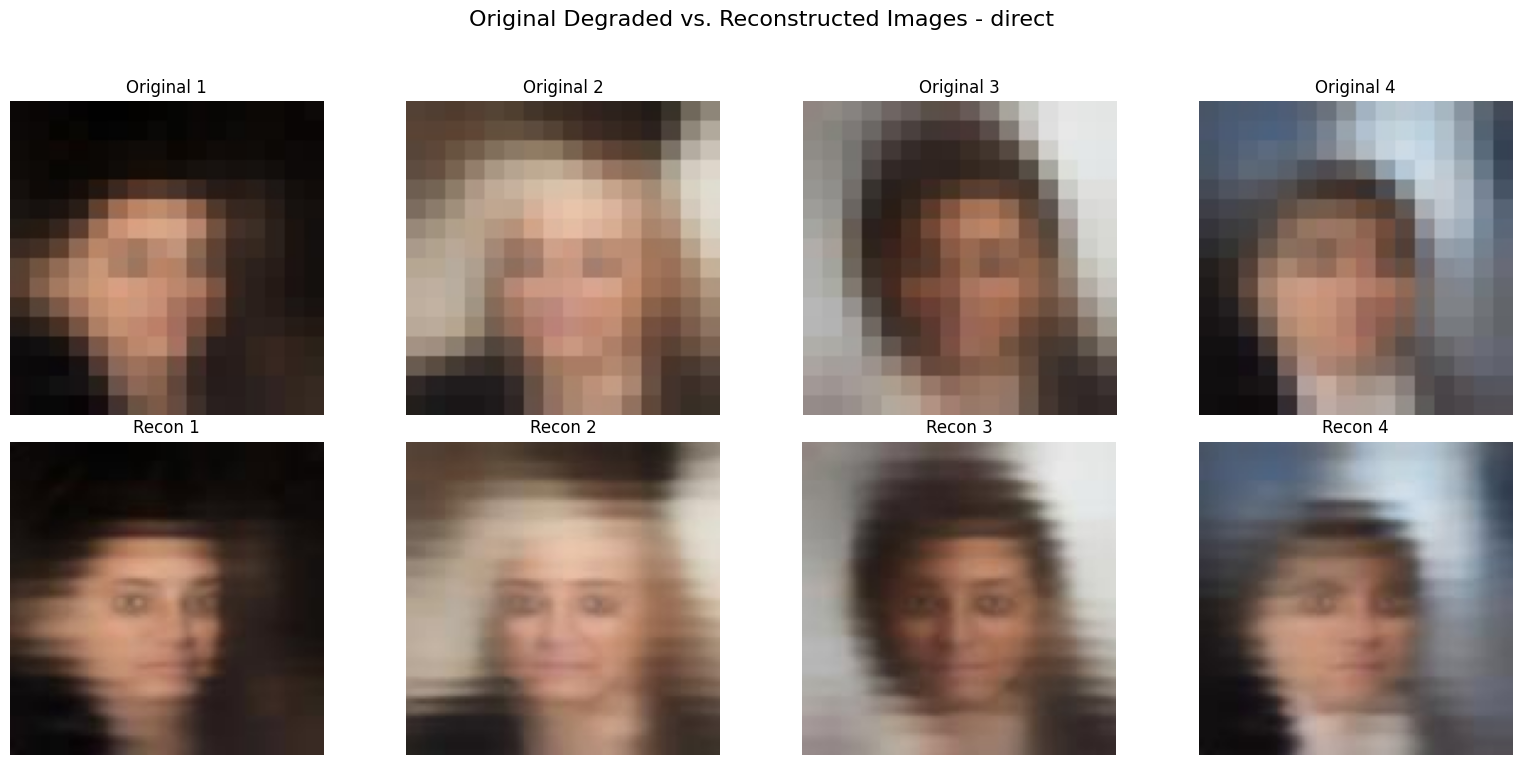

In [ ]:
plot_some_reconstructions(output_directory=output_directory_dir, direct=True)

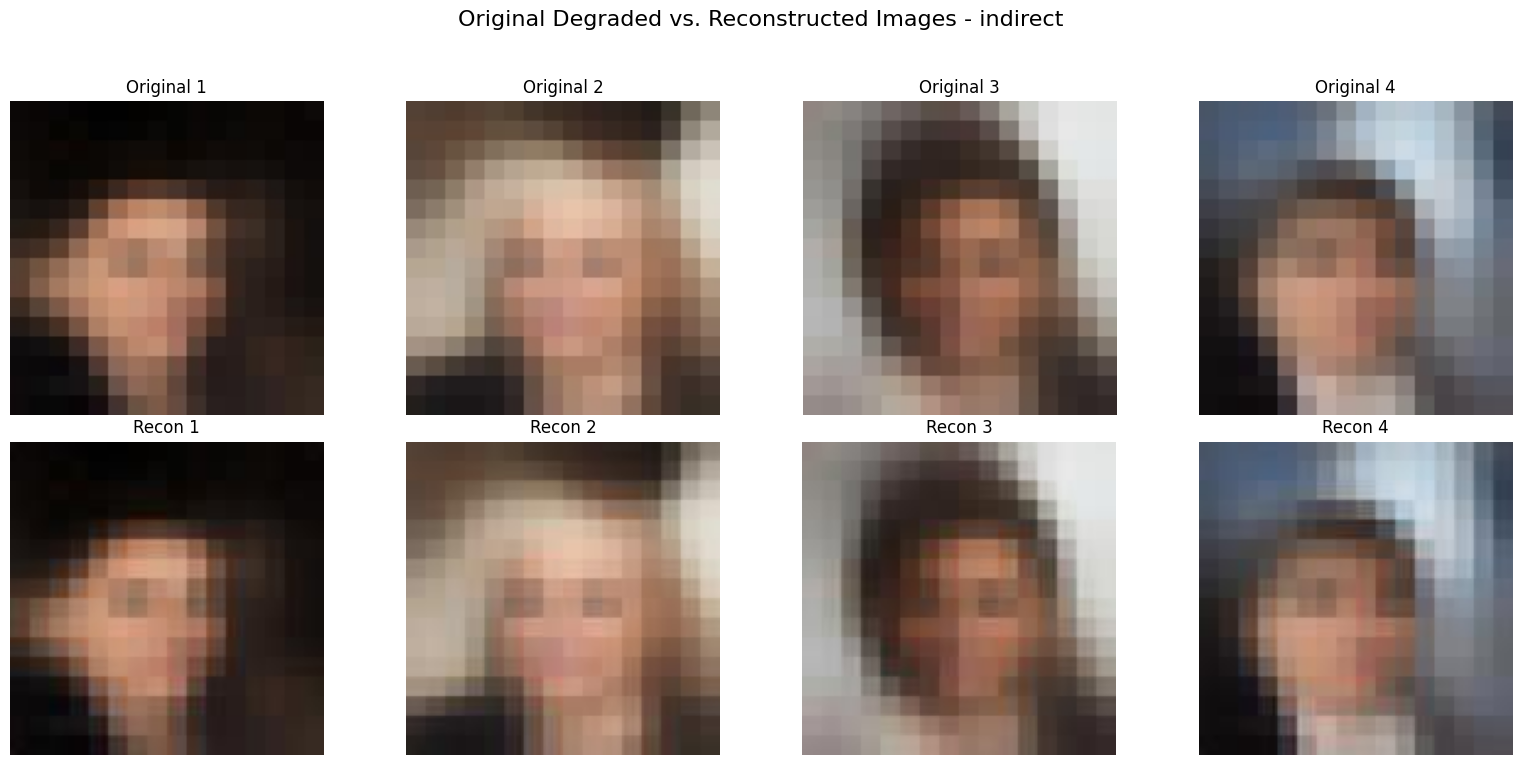

In [ ]:
plot_some_reconstructions(output_directory=output_directory_indir, direct=False)